In [19]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [20]:
class Data:
  def __init__(self, num_train, num_val, num_inputs, batch_size):
    self.num_train = num_train
    self.num_val = num_val
    self.num_inputs = num_inputs
    self.batch_size = batch_size

    n = num_train + num_val
    self.X = torch.randn(n, num_inputs)
    noise = torch.randn(n, 1) * 0.01
    w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
    self.y = torch.matmul(self.X, w) + b + noise

  def get_dataloader(self, train=True):
    if train:
      X = self.X[:self.num_train]
      y = self.y[:self.num_train]
    else:
      X = self.X[self.num_train:]
      y = self.y[self.num_train:]

    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=self.batch_size, shuffle=train)

In [21]:
def l2_penalty(w):
  return (w ** 2).sum() / 2

In [22]:
class WeightDecayScratch:
  def __init__(self, num_inputs, lambd, lr, sigma=0.01):
    self.num_inputs = num_inputs
    self.lambd = lambd
    self.lr = lr

    self.w = torch.randn(num_inputs, 1) * sigma
    self.b = torch.zeros(1)

    self.w.requires_grad_()
    self.b.requires_grad_()

  def forward(self, X):
    return torch.matmul(X, self.w) + self.b

  def loss(self, y_hat, y):
    mse = torch.mean((y_hat - y) ** 2) / 2
    return mse + self.lambd * l2_penalty(self.w)

  def step(self):
    with torch.no_grad():
      self.w -= self.lr * self.w.grad
      self.b -= self.lr * self.b.grad

      self.w.grad.zero_()
      self.b.grad.zero_()


In [23]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
def train_scratch(lambd):
  model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
  num_epochs = 10
  for epoch in range(num_epochs):
    total_loss = 0
    count = 0
    for X, y in data.get_dataloader():
      y_hat = model.forward(X)
      loss = model.loss(y_hat, y)
      loss.backward()
      model.step()
      total_loss += loss.item()
      count += 1

    val_loss = 0
    val_count = 0
    for X, y in data.get_dataloader(train=False):
      with torch.no_grad():
        y_hat = model.forward(X)
        loss = model.loss(y_hat, y)

      val_loss += loss.item()
      val_count += 1

    print(f'Epoch {epoch + 1}: Train Loss =  {total_loss/count:.6f}, Val Loss = {val_loss/val_count:.6f}')
    print('L2 norm of w:', float(l2_penalty(model.w)))

In [24]:
train_scratch(0)

Epoch 1: Train Loss =  0.019802, Val Loss = 0.018667
L2 norm of w: 0.007785411551594734
Epoch 2: Train Loss =  0.007932, Val Loss = 0.018077
L2 norm of w: 0.0078769251704216
Epoch 3: Train Loss =  0.003483, Val Loss = 0.017817
L2 norm of w: 0.008043241687119007
Epoch 4: Train Loss =  0.001622, Val Loss = 0.017725
L2 norm of w: 0.008195233531296253
Epoch 5: Train Loss =  0.000776, Val Loss = 0.017685
L2 norm of w: 0.0083204610273242
Epoch 6: Train Loss =  0.000398, Val Loss = 0.017676
L2 norm of w: 0.008417741395533085
Epoch 7: Train Loss =  0.000209, Val Loss = 0.017679
L2 norm of w: 0.008490636944770813
Epoch 8: Train Loss =  0.000107, Val Loss = 0.017682
L2 norm of w: 0.008542003110051155
Epoch 9: Train Loss =  0.000056, Val Loss = 0.017687
L2 norm of w: 0.008578963577747345
Epoch 10: Train Loss =  0.000030, Val Loss = 0.017695
L2 norm of w: 0.00860621314495802


In [25]:
train_scratch(3) #Using weight decay

Epoch 1: Train Loss =  0.042689, Val Loss = 0.041608
L2 norm of w: 0.006869177799671888
Epoch 2: Train Loss =  0.026034, Val Loss = 0.035691
L2 norm of w: 0.0055097173899412155
Epoch 3: Train Loss =  0.018698, Val Loss = 0.031315
L2 norm of w: 0.004505686927586794
Epoch 4: Train Loss =  0.014681, Val Loss = 0.027907
L2 norm of w: 0.003719552420079708
Epoch 5: Train Loss =  0.011938, Val Loss = 0.025210
L2 norm of w: 0.0031070392578840256
Epoch 6: Train Loss =  0.009924, Val Loss = 0.023058
L2 norm of w: 0.0026160713750869036
Epoch 7: Train Loss =  0.008391, Val Loss = 0.021336
L2 norm of w: 0.0022217468358576298
Epoch 8: Train Loss =  0.007256, Val Loss = 0.019950
L2 norm of w: 0.001920707756653428
Epoch 9: Train Loss =  0.006321, Val Loss = 0.018812
L2 norm of w: 0.0016672988422214985
Epoch 10: Train Loss =  0.005652, Val Loss = 0.017911
L2 norm of w: 0.0014787730760872364


In [26]:
class WeightDecay:
  def __init__(self, num_inputs, wd, lr):
    self.model = nn.Linear(num_inputs, 1)
    self.wd = wd
    self.lr = lr

    self.optimizer = torch.optim.SGD([
        {'params': self.model.weight, 'weight_decay': self.wd},
        {'params': self.model.bias, 'weight_decay': 0}
    ], lr=self.lr)
    self.loss_fn = nn.MSELoss()

  def forward(self, X):
    return self.model(X)

In [27]:
def train_concise(model, data, epochs=10):
  train_losses = []
  val_losses = []
  for epoch in range(epochs):
    total_loss = 0
    count = 0

    for X, y in data.get_dataloader(train=True):
      y_hat = model.forward(X)
      loss = model.loss_fn(y_hat, y)
      model.optimizer.zero_grad()
      loss.backward()
      model.optimizer.step()
      total_loss += loss.item()
      count += 1

    train_loss = total_loss / count
    train_losses.append(train_loss)

    val_loss = 0
    val_count = 0
    with torch.no_grad():
      for X, y in data.get_dataloader(train=False):
        y_hat = model.forward(X)
        loss = model.loss_fn(y_hat, y)
        val_loss += loss.item()
        val_count += 1

    val_loss /= val_count
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")
  return train_losses, val_losses

In [28]:
data = Data(num_train=20, num_val = 100, num_inputs=200, batch_size=5)
model = WeightDecay(num_inputs=200, wd=3, lr=0.01)
train_losses, val_losses = train_concise(model, data)

w = model.model.weight.data
print('L2 norm of w:', float(torch.norm(w)))

Epoch 1: Train Loss = 0.297863, Val Loss = 0.265483
Epoch 2: Train Loss = 0.010606, Val Loss = 0.213166
Epoch 3: Train Loss = 0.001298, Val Loss = 0.172425
Epoch 4: Train Loss = 0.000424, Val Loss = 0.139760
Epoch 5: Train Loss = 0.000349, Val Loss = 0.113988
Epoch 6: Train Loss = 0.000420, Val Loss = 0.093696
Epoch 7: Train Loss = 0.000244, Val Loss = 0.077694
Epoch 8: Train Loss = 0.000483, Val Loss = 0.065070
Epoch 9: Train Loss = 0.000400, Val Loss = 0.055159
Epoch 10: Train Loss = 0.000193, Val Loss = 0.047336
L2 norm of w: 0.15746577084064484


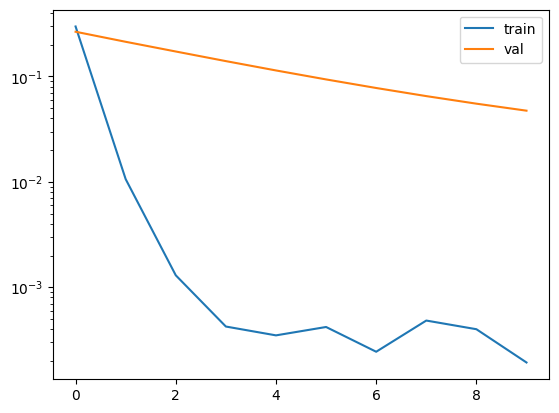

In [29]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.yscale('log')   # same effect as d2l
plt.legend()
plt.show()